# AI-Based Online Exam Cheating Detection System

## Overview
This project presents a hybrid AI system to detect cheating in online exams using behavioral, relational, textual, and biometric analysis.

## Why This Project?
Online exams lack physical supervision, making cheating easier. Traditional systems fail to detect:
- Group cheating
- AI-generated answers
- Identity fraud

## Why These Algorithms?

### 1. Isolation Forest
Used because cheating behavior is rare and different from normal behavior.

### 2. Graph-Based Model (GNN Concept)
Used to detect collusion between students by analyzing relationships.

### 3. BERT Stylometry
Used to detect answer similarity and writing style mismatch.

### 4. Variational Autoencoder (VAE)
Used to detect unknown cheating patterns not seen before.

### 5. Keystroke Dynamics
Used to verify student identity through typing behavior.

### Final Idea
Each algorithm detects a different type of cheating, making the system robust and multi-dimensional.

In [ ]:
!pip install pandas numpy scikit-learn sentence-transformers networkx torch

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 50  # students

df = pd.DataFrame({
    "student_id": range(n),
    "time_taken": np.random.randint(5, 60, n),
    "tab_switches": np.random.randint(0, 10, n),
    "typing_speed": np.random.randint(20, 100, n),
    "idle_time": np.random.randint(0, 20, n)
})

# simulate answers
answers = [
    "Machine learning is a subset of AI",
    "Artificial intelligence includes machine learning",
    "Deep learning uses neural networks",
    "Supervised learning uses labeled data"
]

df["answer"] = np.random.choice(answers, n)

df.head()

,student_id,time_taken,tab_switches,typing_speed,idle_time,answer
0,0,43,1,27,5,Supervised learning uses labeled data
1,1,56,3,54,11,Artificial intelligence includes machine learning
2,2,33,8,54,11,Artificial intelligence includes machine learning
3,3,19,1,52,19,Artificial intelligence includes machine learning
4,4,47,9,24,10,Deep learning uses neural networks


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

features = df[["time_taken", "tab_switches", "typing_speed", "idle_time"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

iso = IsolationForest(contamination=0.1)
df["behavior_flag"] = iso.fit_predict(X_scaled)

NameError: name 'df' is not defined

In [ ]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(X_scaled)

G = nx.Graph()

for i in range(len(df)):
    G.add_node(i)

for i in range(len(df)):
    for j in range(i+1, len(df)):
        if sim[i][j] > 0.95:
            G.add_edge(i, j)

groups = list(nx.connected_components(G))
groups

[{0, 14},
 {1},
 {2},
 {3, 18, 26},
 {4, 27},
 {5},
 {6, 16, 29, 36, 37},
 {7},
 {8},
 {9},
 {10},
 {11},
 {12},
 {13},
 {15},
 {17},
 {19},
 {20},
 {21, 31},
 {22},
 {23, 35},
 {24},
 {25},
 {28},
 {30, 39, 42},
 {32, 38},
 {33},
 {34},
 {40},
 {41},
 {43, 46},
 {44},
 {45},
 {47},
 {48},
 {49}]

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(df["answer"].tolist())

sim_text = cosine_similarity(embeddings)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
text_cheat = []

for i in range(len(df)):
    for j in range(i+1, len(df)):
        if sim_text[i][j] > 0.9:
            text_cheat.append((i, j))

text_cheat[:5]

[(0, 6), (0, 7), (0, 10), (0, 13), (0, 16)]

In [ ]:
import torch
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 16)
        self.fc4 = nn.Linear(16, input_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        z = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(z))
        return self.fc4(x)

model_vae = VAE(X_scaled.shape[1])
optimizer = torch.optim.Adam(model_vae.parameters(), lr=0.01)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

for epoch in range(30):
    output = model_vae(X_tensor)
    loss = ((output - X_tensor)**2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

loss.item()

0.2785327136516571

In [ ]:
df["typing_variance"] = np.random.rand(len(df))

df["identity_flag"] = df["typing_variance"] > 0.8

In [ ]:
df["final_flag"] = "Normal"

# Behavior
df.loc[df["behavior_flag"] == -1, "final_flag"] = "Behavior Cheating"

# Identity
df.loc[df["identity_flag"] == True, "final_flag"] = "Identity Cheating"

# Group
for group in groups:
    if len(group) > 1:
        for student in group:
            df.loc[student, "final_flag"] = "Group Cheating"

df[["student_id", "final_flag"]].head(10)

,student_id,final_flag
0,0,Group Cheating
1,1,Normal
2,2,Normal
3,3,Group Cheating
4,4,Group Cheating
5,5,Normal
6,6,Group Cheating
7,7,Normal
8,8,Behavior Cheating
9,9,Normal


In [ ]:
# Count final predictions
df["final_flag"].value_counts()

,count
final_flag,
Group Cheating,23
Normal,22
Behavior Cheating,3
Identity Cheating,2


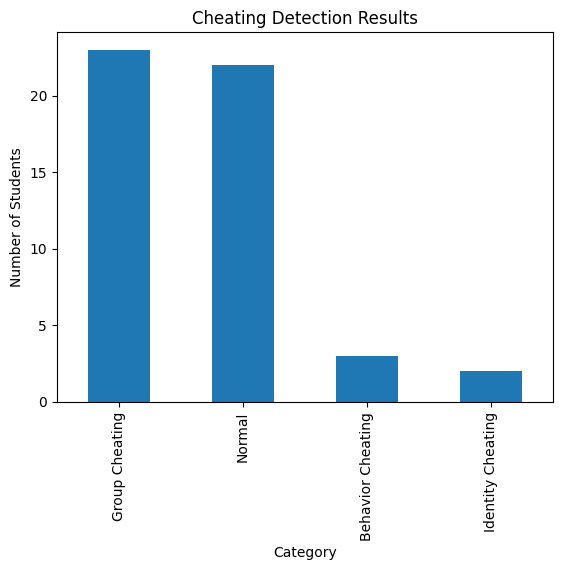

In [ ]:
import matplotlib.pyplot as plt

df["final_flag"].value_counts().plot(kind='bar')
plt.title("Cheating Detection Results")
plt.xlabel("Category")
plt.ylabel("Number of Students")
plt.show()


## Visualization

A bar graph is used to visualize the distribution of detected cheating categories.

This helps in understanding:
- How many students were flagged
- Which type of cheating is most common

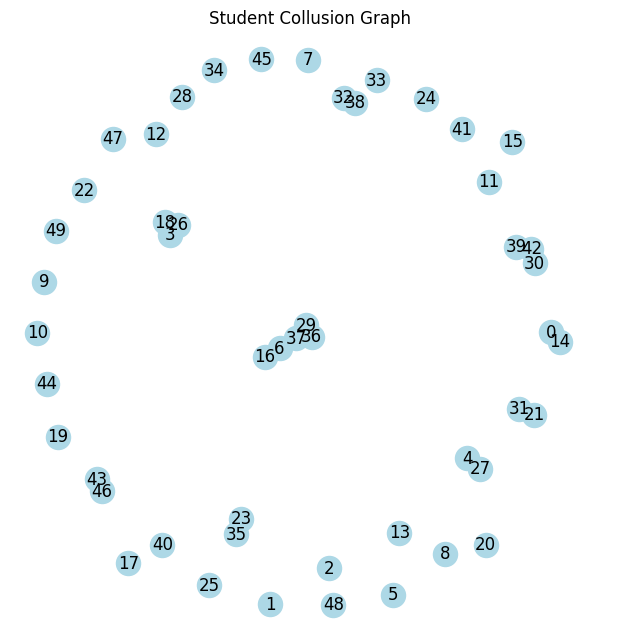

In [ ]:
plt.figure(figsize=(6,6))
nx.draw(G, with_labels=True, node_color='lightblue')
plt.title("Student Collusion Graph")
plt.show()

## Graph Visualization

This graph represents relationships between students.

- Each node → student
- Each edge → high similarity between students

Clusters in the graph indicate possible group cheating.

In [ ]:
df.head(15)

,student_id,time_taken,tab_switches,typing_speed,idle_time,answer,behavior_flag,typing_variance,identity_flag,final_flag
0,0,43,1,27,5,Supervised learning uses labeled data,1,0.465598,False,Group Cheating
1,1,56,3,54,11,Artificial intelligence includes machine learning,1,0.542645,False,Normal
2,2,33,8,54,11,Artificial intelligence includes machine learning,1,0.286541,False,Normal
3,3,19,1,52,19,Artificial intelligence includes machine learning,1,0.590833,False,Group Cheating
4,4,47,9,24,10,Deep learning uses neural networks,1,0.030500,False,Group Cheating
5,5,12,8,60,6,Deep learning uses neural networks,1,0.037348,False,Normal
6,6,25,9,47,0,Supervised learning uses labeled data,1,0.822601,True,Group Cheating
7,7,43,4,26,0,Supervised learning uses labeled data,1,0.360191,False,Normal
8,8,23,1,92,19,Machine learning is a subset of AI,-1,0.127061,False,Behavior Cheating
9,9,27,3,91,12,Machine learning is a subset of AI,1,0.522243,False,Normal


## Sample Output

The table shows:
- Student ID
- Behavior flag
- Identity flag
- Final cheating classification

This represents the final output of the system.

## Why These Algorithms Were Used

### Isolation Forest
Used for detecting abnormal student behavior without labeled data.

### Graph-Based Model
Used to detect collusion between students.

### BERT
Used for detecting answer similarity and writing patterns.

### VAE
Used to detect unknown or unseen cheating patterns.

### Keystroke Dynamics
Used for identity verification.

### Final Insight
Each algorithm targets a different type of cheating, making the system robust.

## Limitations

- Dataset is simulated, not real-world
- False positives may occur
- Keystroke data is approximated
- Real-time deployment requires more infrastructure

## Future Scope

- Integration with webcam-based monitoring
- Real-time cheating detection system
- Use of deep learning for video analysis
- Deployment as a web application

## Conclusion

This project demonstrates a hybrid AI-based system for detecting cheating in online exams.

The system combines multiple techniques:
- Behavioral analysis
- Graph-based detection
- Text similarity
- Identity verification

This multi-layer approach improves accuracy and robustness compared to single-model systems.